# Using Data Notes as Quality Flags

This notebook uses the **note1** meanings as data-quality flags. Some records are complete enough to analyze, but the note tells us to be careful about how they are used.

The goal is to teach that data cleaning is not only about blank cells. A value can be present and still deserve a closer look because the field note says the plot, measurement, or survey condition was unusual.

---

## Load the simplified dataset

This lesson starts from the merged project dataset. That dataset already includes **note1_meaning**, so we can compare analyses with and without certain note categories.

In [1]:
import pandas as pd
from IPython.display import Image, display

analysis_df = pd.read_csv("../../output/merged_full.csv")
analysis_df.head()

,record_id,month,day,year,plot_id,note1,species_id,sex,hindfoot_length,weight,genus,species_name,taxa,plot_type,note1_meaning
0,63,8,19,1977,3.0,NaN,DM,M,35.0,40.0,Dipodomys,merriami,Rodent,Long-term Krat Exclosure,NaN
1,64,8,19,1977,7.0,NaN,DM,M,37.0,48.0,Dipodomys,merriami,Rodent,Rodent Exclosure,NaN
2,65,8,19,1977,4.0,NaN,DM,F,34.0,29.0,Dipodomys,merriami,Rodent,Control,NaN
3,66,8,19,1977,4.0,NaN,DM,F,35.0,46.0,Dipodomys,merriami,Rodent,Control,NaN
4,67,8,19,1977,7.0,NaN,DM,M,35.0,36.0,Dipodomys,merriami,Rodent,Rodent Exclosure,NaN


## Look at which notes remain after measurement cleaning

The simplified dataset has already dropped missing weight, missing hindfoot_length, and invalid sex values. That means many severe missing-data records are gone. The remaining notes are useful for asking whether some complete records should still be handled cautiously.

In [2]:
note_summary = (
    analysis_df.groupby(['note1', 'note1_meaning'], dropna=False)
    .agg(
        n_records=('record_id', 'size'),
        mean_weight=('weight', 'mean'),
        mean_hindfoot_length=('hindfoot_length', 'mean')
    )
    .reset_index()
    .sort_values('n_records', ascending=False)
)

note_summary.head(15)

,note1,note1_meaning,n_records,mean_weight,mean_hindfoot_length
13,NaN,NaN,68483,32.196341,26.835915
1,3.0,stake numbers suspect,831,26.454874,24.569194
3,6.0,gates open (5 or more),398,46.449749,33.653266
5,9.0,outside plot on exterior grid,386,58.966321,36.743523
2,5.0,gates open+non-survey,307,52.459283,33.423453
0,1.0,"some missing data (i.e. stake missing, mass, s...",300,30.320000,26.426667
4,8.0,non-survey,71,50.084507,34.943662
6,10.0,plot fence down,62,30.241935,26.177419
7,11.0,plot number suspect,54,22.777778,23.870370
8,12.0,mass or hindfootlength suspect,13,25.076923,23.000000


## Compare note groups to the overall average

This visual compares the average weight for records with a note to the overall average in the cleaned dataset. Large differences do not automatically mean a note is bad. They do mean the note group deserves attention before we combine it with every other record.

In [3]:
noted_weight_df = note_summary.dropna(subset=['note1']).copy()
noted_weight_df = noted_weight_df.sort_values('n_records', ascending=False).head(10)
noted_weight_df['note_label'] = noted_weight_df['note1'].astype(int).astype(str)

overall_mean_weight = analysis_df['weight'].mean()
noted_weight_df[['note_label', 'note1_meaning', 'n_records', 'mean_weight']]

,note_label,note1_meaning,n_records,mean_weight
1,3,stake numbers suspect,831,26.454874
3,6,gates open (5 or more),398,46.449749
5,9,outside plot on exterior grid,386,58.966321
2,5,gates open+non-survey,307,52.459283
0,1,"some missing data (i.e. stake missing, mass, s...",300,30.320000
4,8,non-survey,71,50.084507
6,10,plot fence down,62,30.241935
7,11,plot number suspect,54,22.777778
8,12,mass or hindfootlength suspect,13,25.076923
9,14,plot not completely trapped (note number of tr...,4,22.250000


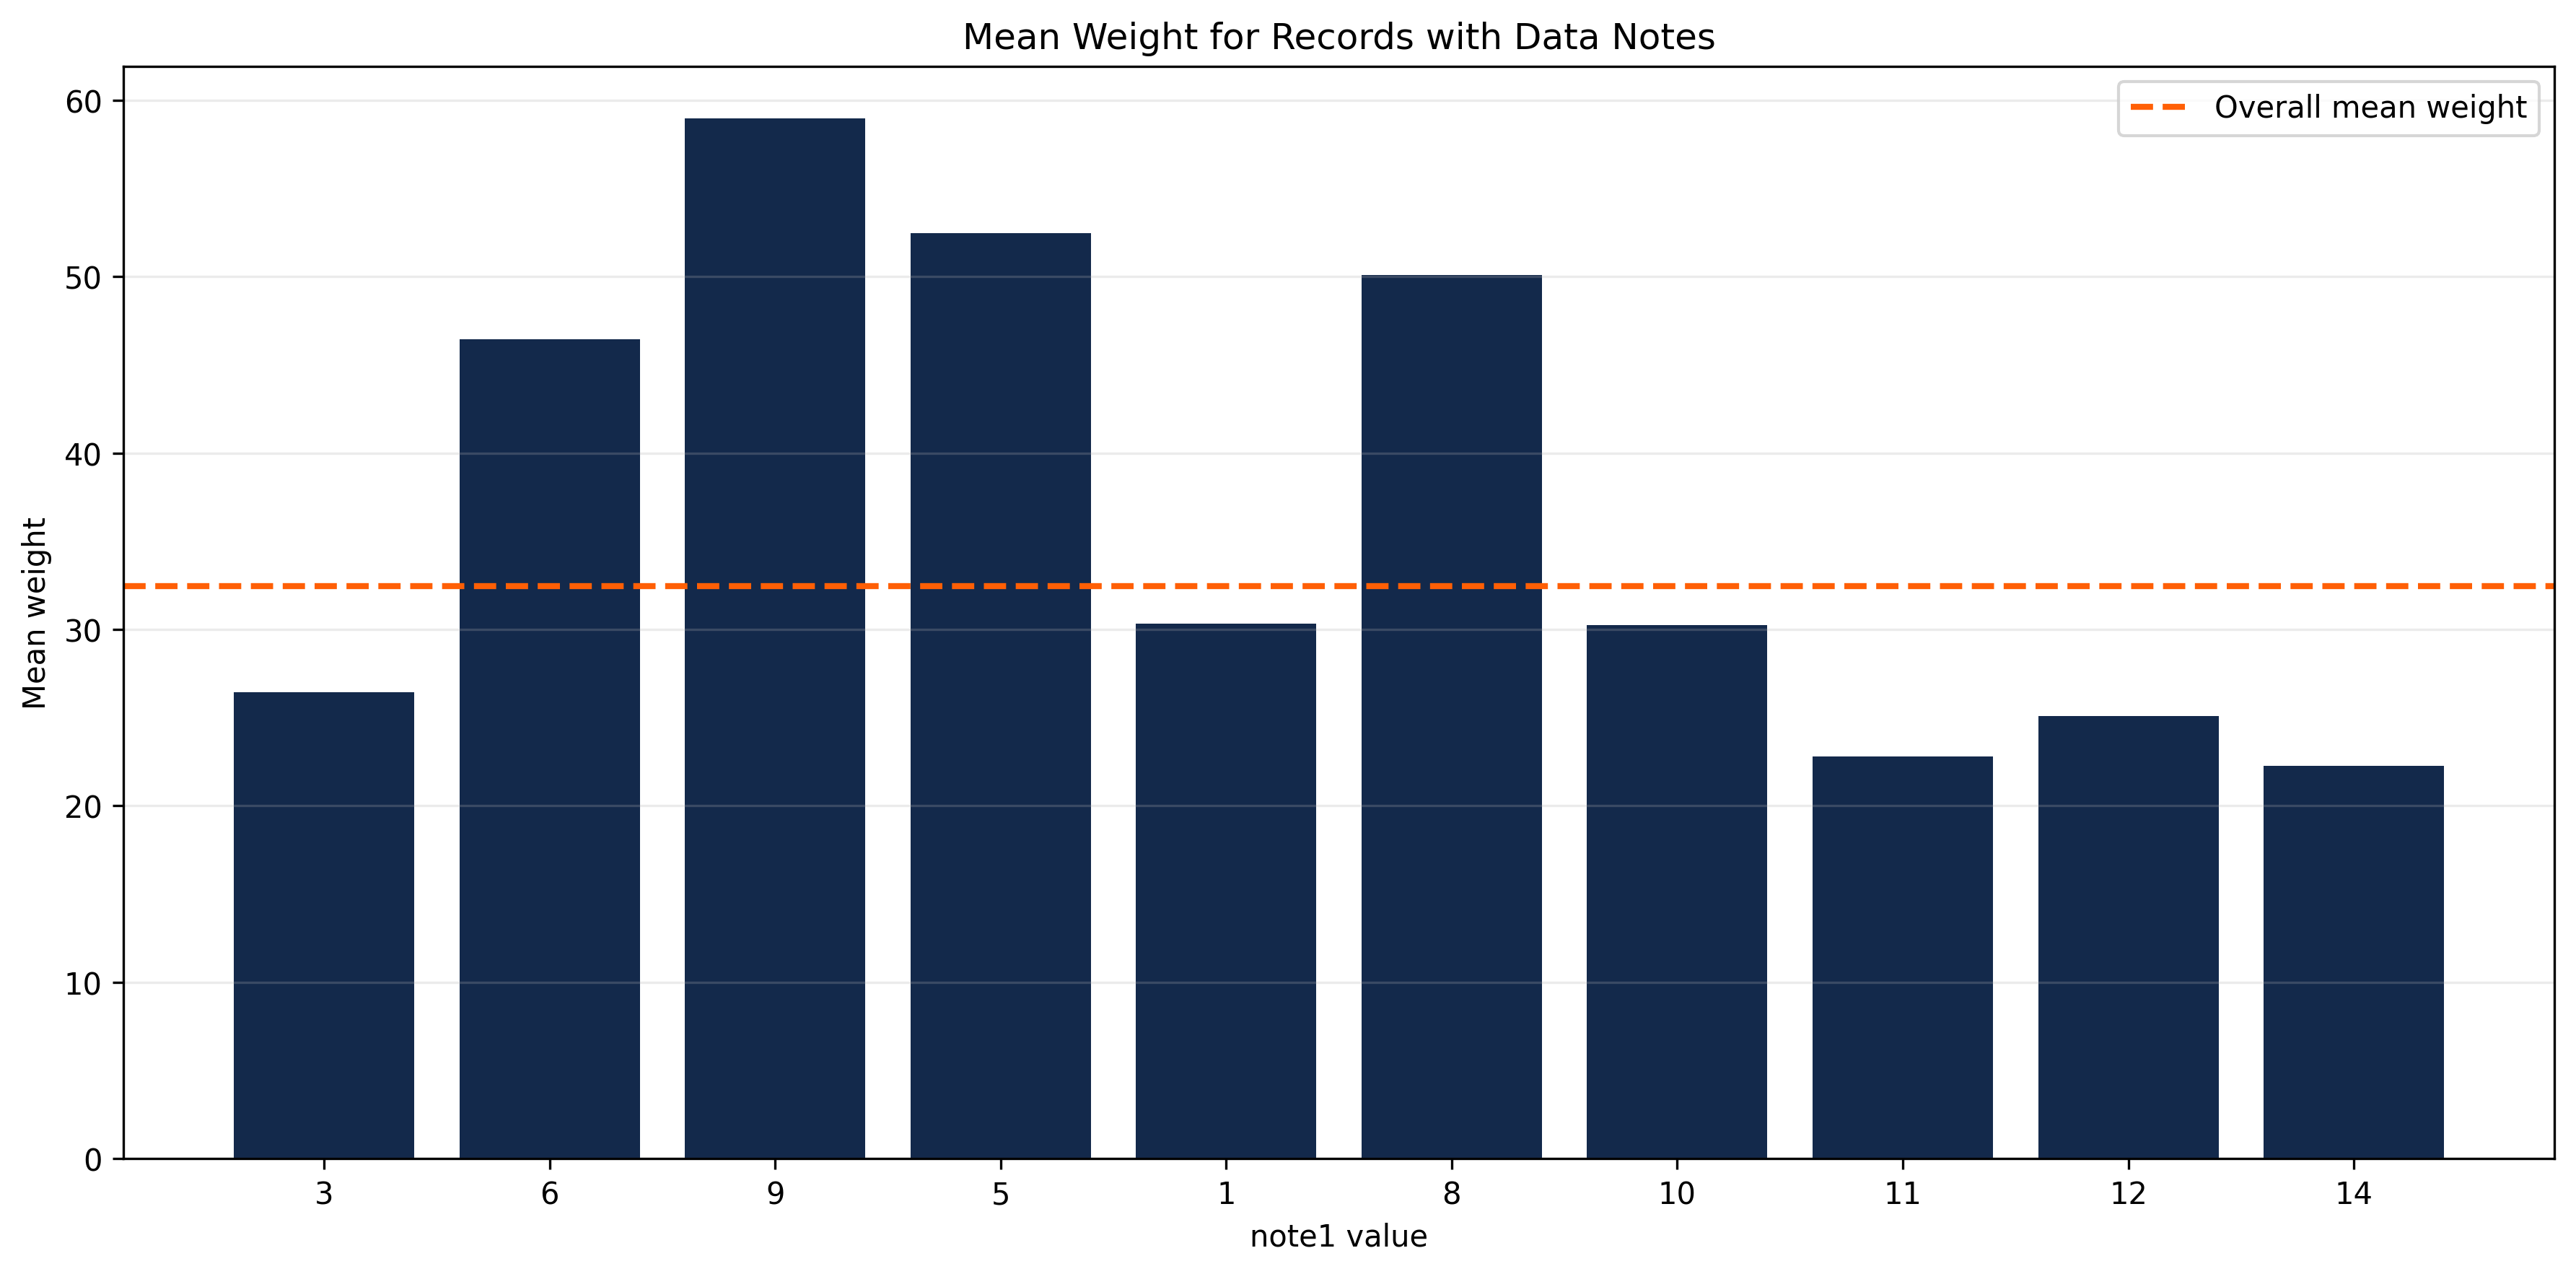

In [4]:

# FIG 6.1
display(Image(filename="../../images/fig_6_1.png"))


## Test how filtering choices change the result

The next comparison asks a simple question: what is the average weight by plot type?

Instead of using one cleaned dataset, we create several analysis versions:
- all cleaned records
- exclude suspect measurements
- exclude outside-plot captures
- exclude non-survey and gates-open records
- exclude all of those caution notes together

This teaches that filtering should be connected to the question. If the question is about animals inside experimental plots, outside-plot captures may not belong. If the question is about body measurements, suspect mass or hindfoot records may not belong.

In [5]:
filter_sets = {
    'All cleaned records': [],
    'Exclude suspect measurements': [12],
    'Exclude outside-plot captures': [9],
    'Exclude non-survey/gates-open': [5, 6, 8],
    'Exclude all caution notes': [5, 6, 8, 9, 12]
}

filter_results = []

for label, excluded_notes in filter_sets.items():
    filtered = analysis_df.copy()
    if excluded_notes:
        filtered = filtered[~filtered['note1'].isin(excluded_notes)].copy()

    filter_results.append({
        'analysis_version': label,
        'n_records': len(filtered),
        'mean_weight': filtered['weight'].mean(),
        'mean_hindfoot_length': filtered['hindfoot_length'].mean(),
        'n_notes_excluded': len(excluded_notes)
    })

filter_results_df = pd.DataFrame(filter_results)
filter_results_df

,analysis_version,n_records,mean_weight,mean_hindfoot_length,n_notes_excluded
0,All cleaned records,70917,32.442531,26.933204,0
1,Exclude suspect measurements,70904,32.443882,26.933925,1
2,Exclude outside-plot captures,70531,32.297373,26.879514,1
3,Exclude non-survey/gates-open,70141,32.257581,26.858556,3
4,Exclude all caution notes,69742,32.111095,26.804565,5


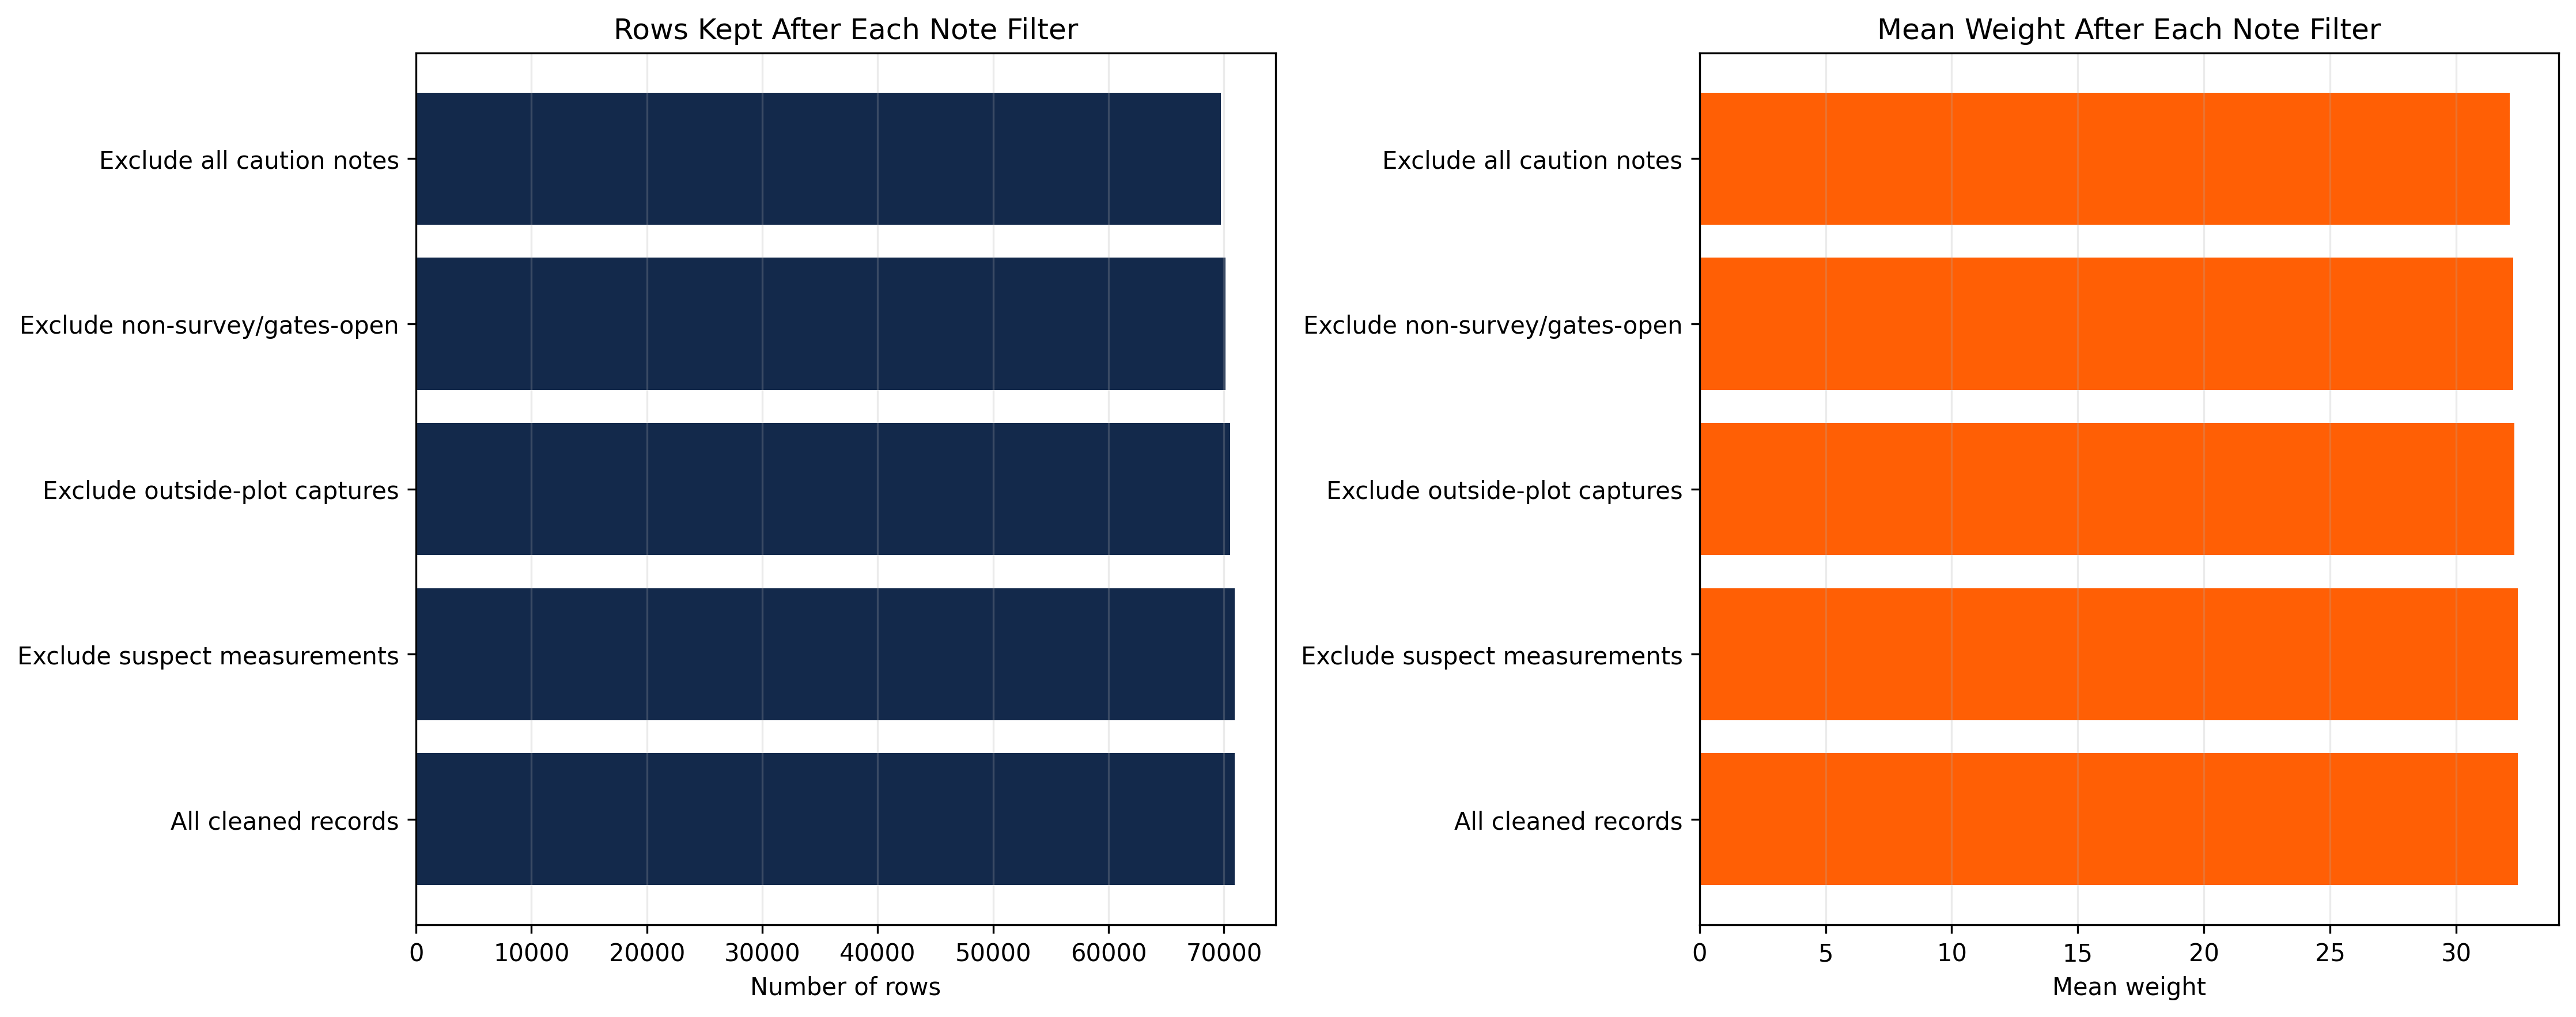

In [6]:

# FIG 6.2
display(Image(filename="../../images/fig_6_2.png"))


## Look at plot type after filtering

This final table keeps the same question but adds plot type. If the filtering choice changes one plot type more than another, the comparison between plot types can shift.

In [7]:
plot_type_comparisons = []

for label, excluded_notes in filter_sets.items():
    filtered = analysis_df.copy()
    if excluded_notes:
        filtered = filtered[~filtered['note1'].isin(excluded_notes)].copy()

    grouped = (
        filtered.groupby('plot_type', dropna=False)
        .agg(mean_weight=('weight', 'mean'), n_records=('record_id', 'size'))
        .reset_index()
    )
    grouped['analysis_version'] = label
    plot_type_comparisons.append(grouped)

plot_type_comparisons_df = pd.concat(plot_type_comparisons, ignore_index=True)
plot_type_comparisons_df.head(10)

,plot_type,mean_weight,n_records,analysis_version
0,Control,36.337522,31118,All cleaned records
1,Long-term Krat Exclosure,23.900773,11519,All cleaned records
2,Rodent Exclosure,27.454150,9204,All cleaned records
3,Short-term Krat Exclosure,30.317821,12227,All cleaned records
4,Spectab exclosure,39.612588,6848,All cleaned records
5,NaN,12.000000,1,All cleaned records
6,Control,36.338187,31113,Exclude suspect measurements
7,Long-term Krat Exclosure,23.898923,11516,Exclude suspect measurements
8,Rodent Exclosure,27.458102,9201,Exclude suspect measurements
9,Short-term Krat Exclosure,30.317821,12227,Exclude suspect measurements


## Conclusion

Data notes are part of the data. They help explain why a record may need special treatment even when the main measurement columns are complete.

A good rule is to filter based on the analysis question. If the note directly affects the variable or comparison being studied, pay attention to it. If the note does not affect the question, it may be better to keep the record and document the decision.